In [1]:
%matplotlib inline

# Households

* **Input**: cleaned and optimized pickeled DataFrames (persons.csv and households.csv) for 20XX
* **Output**: Visualisations

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Settings" data-toc-modified-id="Settings-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Settings</a></span></li><li><span><a href="#Loading-Data" data-toc-modified-id="Loading-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading Data</a></span><ul class="toc-item"><li><span><a href="#SynPop" data-toc-modified-id="SynPop-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>SynPop</a></span></li><li><span><a href="#BFS---Predictions" data-toc-modified-id="BFS---Predictions-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>BFS - Predictions</a></span></li></ul></li><li><span><a href="#Analysis" data-toc-modified-id="Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Analysis</a></span><ul class="toc-item"><li><span><a href="#Household-Size" data-toc-modified-id="Household-Size-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Household Size</a></span></li><li><span><a href="#Number-of-Children" data-toc-modified-id="Number-of-Children-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Number of Children</a></span></li></ul></li><li><span><a href="#Export-Notebook-to-HTML" data-toc-modified-id="Export-Notebook-to-HTML-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Export Notebook to HTML</a></span></li></ul></div>

In [2]:
import os
import sys
import pandas as pd

from matplotlib import pyplot as plt

In [3]:
sys.path.append(r'\\Filer16L\P-V160L\SIMBA.A11244\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
import synpop.utils as utils

##  Settings

In [5]:
YEAR_IST = 2017
YEAR = 2030

DATA_DIR_IST = r'\\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed'
SYNPOP_PERSONS_FILE_IST = os.path.join(DATA_DIR_IST, 'persons_{}.pickle.gzip'.format(YEAR_IST))

DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2030\02_preprocessed'
SYNPOP_PERSONS_FILE = os.path.join(DATA_DIR, 'persons_{}.pickle.gzip'.format(YEAR))

# Download from: https://www.bfs.admin.ch/bfs/fr/home/statistiques/population/evolution-future/scenarios-menages.assetdetail.3623353.html
BFS_HOUSEHOLD_STATS_EXCEL = r'\\Filer16L\P-V160L\SIMBA.A11244\40_Projekte\20190101_Synpop_2030\20_Arbeiten\20_Daten_BFS\su-f-01.03.03.03.xlsx'

**Plot Export Settings**

In [6]:
SAVE_FIGURES = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.2

In [7]:
utils.create_dir(OUTPUT_DIR)

2020-02-18 14:34:35,170 - INFO - synpop.utils: "./outputs" exists already


## Loading Data

### SynPop

In [8]:
%%time
persons = pd.read_pickle(SYNPOP_PERSONS_FILE, compression='gzip')
persons['is_child'] = (persons['age'] < 18).astype(int)

Wall time: 12.4 s


In [9]:
%%time
households = (persons.groupby('household_id')
                     .agg({'person_id': 'count', 'is_child': sum})
                     .rename(columns={'person_id': 'members', 'is_child': 'children'})
             )

Wall time: 8.19 s


In [10]:
%%time
persons_ist = pd.read_pickle(SYNPOP_PERSONS_FILE_IST, compression='gzip')
persons_ist['is_child'] = (persons_ist['age'] < 18).astype(int)

Wall time: 12.1 s


In [11]:
%%time
households_ist = (persons_ist.groupby('household_id')
                             .agg({'person_id': 'count', 'is_child': sum})
                             .rename(columns={'person_id': 'members', 'is_child': 'children'})
                 )

Wall time: 7.09 s


### BFS - Predictions

https://www.bfs.admin.ch/bfs/fr/home/statistiques/population/evolution-future/scenarios-menages.assetdetail.3623353.html

In [12]:
pc_households_bsf_pred = (pd.read_excel(BFS_HOUSEHOLD_STATS_EXCEL, header=2)
                          .iloc[11:17]
                          .drop('Unnamed: 0', axis=1)
                          )

pc_households_bsf_pred.index = [1, 2, 3, 4, 5, 6]
pc_households_bsf_pred.index.name = 'members'

In [13]:
bfs_pred = pc_households_bsf_pred[[YEAR_IST, YEAR]]
bfs_pred = bfs_pred.rename(columns={YEAR: f'BFS-{YEAR}', YEAR_IST: f'BFS-{YEAR_IST}'})
bfs_pred

,BFS-2017,BFS-2030
members,,
1,35.2744,36.172348
2,32.7955,33.439148
3,13.1172,12.499318
4,12.7209,12.049303
5,4.35238,4.150155
6,1.73959,1.689729


## Analysis

### Household Size

In [14]:
members_per_hh = households.reset_index().groupby('members').count().iloc[:, 0]
pc_members_per_hh = (members_per_hh / members_per_hh.sum() * 100).rename(f'SynPop{YEAR}').iloc[:6]

members_per_hh_ist = households_ist.reset_index().groupby('members').count().iloc[:, 0]
pc_members_per_hh_ist = (members_per_hh_ist / members_per_hh_ist.sum() * 100).rename(f'SynPop{YEAR_IST}').iloc[:6]

2020-02-18 14:35:15,595 - INFO - numexpr.utils: NumExpr defaulting to 8 threads.


In [15]:
pd.concat([pc_members_per_hh_ist, pc_members_per_hh], axis=1)

,SynPop2017,SynPop2030
members,,
1,36.833681,29.820092
2,31.909936,41.974594
3,12.944703,13.951950
4,12.395540,8.586526
5,4.182589,3.474446
6,1.149372,1.332624


**Plotting SynPop vs. BFS**

In [16]:
hh_sizes_stats = pd.concat([bfs_pred, pc_members_per_hh_ist, pc_members_per_hh], axis=1)

In [17]:
hh_sizes_stats

,BFS-2017,BFS-2030,SynPop2017,SynPop2030
members,,,,
1,35.2744,36.172348,36.833681,29.820092
2,32.7955,33.439148,31.909936,41.974594
3,13.1172,12.499318,12.944703,13.951950
4,12.7209,12.049303,12.395540,8.586526
5,4.35238,4.150155,4.182589,3.474446
6,1.73959,1.689729,1.149372,1.332624


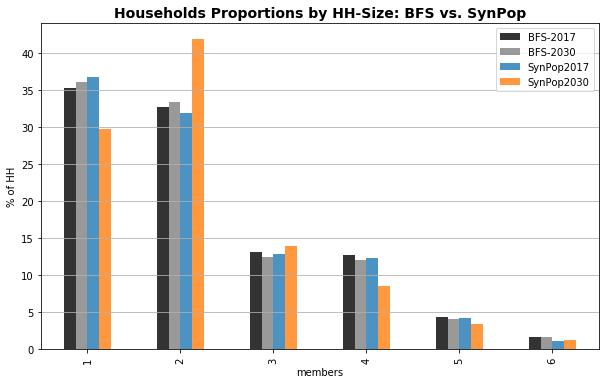

In [18]:
ax = hh_sizes_stats.plot.bar(figsize=(10, 6), alpha=0.8, color=['k', 'grey', 'C0', 'C1'])
ax.grid(axis='y')
plt.ylabel('% of HH')
title = 'Households Proportions by HH-Size: BFS vs. SynPop'
_ = ax.set_title(title, fontdict={'fontsize': 14, 'fontweight': 'bold'})

if SAVE_FIGURES:
    fig_file_name = '05-01_BFS_vs_SynPop{}_vs_SynPop{}_hh_sizes.{}'.format(YEAR_IST, YEAR, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)

### Number of Children

In [19]:
children_per_hh = households.groupby('children').sum().rename(columns={'members': 'nbr_hh'})
children_per_hh['SynPop{}'.format(YEAR)] = children_per_hh['nbr_hh'] / children_per_hh['nbr_hh'].sum()

children_per_hh_ist = households_ist.groupby('children').sum().rename(columns={'members': 'nbr_hh'})
children_per_hh_ist['SynPop{}'.format(YEAR_IST)] = children_per_hh_ist['nbr_hh'] / children_per_hh_ist['nbr_hh'].sum()

prop_hh_nbr_children = pd.merge(children_per_hh_ist.iloc[:,1], children_per_hh.iloc[:,1], left_index=True, right_index=True)

In [20]:
prop_hh_nbr_children.tail()

,SynPop2017,SynPop2030
children,,
60,0.000011,0.000018
62,0.000019,0.000016
74,0.000011,0.000035
98,0.000050,0.000036
102,0.000020,0.000029


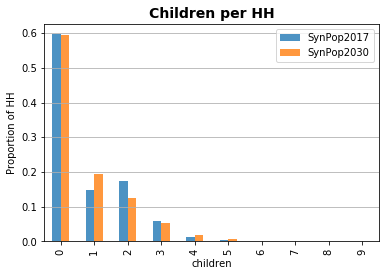

In [21]:
ax = prop_hh_nbr_children.iloc[:10].plot.bar(alpha=0.8)
ax.grid(axis='y')
plt.ylabel('Proportion of HH')
title = 'Children per HH'
_ = ax.set_title(title, fontdict={'fontsize': 14, 'fontweight': 'bold'})

if SAVE_FIGURES:
    fig_file_name = '05-02_SynPop{}_vs_SynPop{}_children_per_hh.{}'.format(YEAR_IST, YEAR, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)

## Export Notebook to HTML

In [22]:
### Write notebook to a html file
!jupyter nbconvert --to html 10_Households.ipynb

[NbConvertApp] Converting notebook 10_Households.ipynb to html
[NbConvertApp] Writing 309941 bytes to 10_Households.html
